# Singapore HDB Resale Price Analysis

216,375 resale transactions, January 2017 to September 2025. Source: data.gov.sg.

Questions I wanted to answer:

1. Which towns are the most and least expensive?
2. Does a higher floor actually cost more?
3. Is there really a price cliff once the remaining lease drops below 60 years?
4. Has the gap between towns changed since 2017?

**A note on method.** Three of the four questions turn out to have the same trap in them: a
difference that looks like it belongs to the variable being measured actually belongs to the
town. Most of the work below is about telling those two apart, and about checking the sample
size behind an average before quoting it.

## Load and inspect

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv')

print("Rows:", len(df))
print("Columns:", df.columns.tolist())
df.head()

Rows: 216375
Columns: ['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'remaining_lease', 'resale_price']


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 216375 entries, 0 to 216374
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                216375 non-null  str    
 1   town                 216375 non-null  str    
 2   flat_type            216375 non-null  str    
 3   block                216375 non-null  str    
 4   street_name          216375 non-null  str    
 5   storey_range         216375 non-null  str    
 6   floor_area_sqm       216375 non-null  float64
 7   flat_model           216375 non-null  str    
 8   lease_commence_date  216375 non-null  int64  
 9   remaining_lease      216375 non-null  str    
 10  resale_price         216375 non-null  float64
dtypes: float64(2), int64(1), str(8)
memory usage: 18.2 MB


In [4]:
df.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,216375.000000,216375.000000,2.163750e+05
mean,96.819319,1996.397176,5.209915e+05
std,24.023993,14.273853,1.845642e+05
min,31.000000,1966.000000,1.400000e+05
25%,82.000000,1985.000000,3.850000e+05
50%,93.000000,1997.000000,4.900000e+05
75%,112.000000,2011.000000,6.250000e+05
max,366.700000,2022.000000,1.658888e+06


In [5]:
print("Towns:", df['town'].nunique())
print("Flat types:", df['flat_type'].unique())
print("Price range:", df['resale_price'].min(), "~", df['resale_price'].max())

Towns: 26


Flat types: <StringArray>
[          '2 ROOM',           '3 ROOM',           '4 ROOM',
           '5 ROOM',        'EXECUTIVE',           '1 ROOM',
 'MULTI-GENERATION']
Length: 7, dtype: str
Price range: 140000.0 ~ 1658888.0


## Derived columns

Three columns I use throughout:

- `price_per_sqm` - flats differ a lot in size, so total price alone is not comparable
- `year` - to look at change over time
- `lease_years` - `remaining_lease` is text like `"61 years 04 months"`, so it needs parsing

In [6]:
df['price_per_sqm'] = df['resale_price'] / df['floor_area_sqm']
df['year'] = pd.to_datetime(df['month']).dt.year

# "61 years 04 months" -> 61.33
years = df['remaining_lease'].str.extract(r'(\d+)\s*year')[0].astype(float)
months = df['remaining_lease'].str.extract(r'(\d+)\s*month')[0].astype(float).fillna(0)
df['lease_years'] = years + months / 12

df[['month', 'town', 'flat_type', 'storey_range', 'remaining_lease', 'lease_years', 'price_per_sqm']].head()

,month,town,flat_type,storey_range,remaining_lease,lease_years,price_per_sqm
0,2017-01,ANG MO KIO,2 ROOM,10 TO 12,61 years 04 months,61.333333,5272.727273
1,2017-01,ANG MO KIO,3 ROOM,01 TO 03,60 years 07 months,60.583333,3731.343284
2,2017-01,ANG MO KIO,3 ROOM,01 TO 03,62 years 05 months,62.416667,3910.447761
3,2017-01,ANG MO KIO,3 ROOM,04 TO 06,62 years 01 month,62.083333,3897.058824
4,2017-01,ANG MO KIO,3 ROOM,01 TO 03,62 years 05 months,62.416667,3955.223881


## 1. Price by town

Straightforward group-by. This one is safe to read at face value.

In [7]:
town_price = df.groupby('town')['resale_price'].mean().sort_values(ascending=False)

print("Most expensive:", town_price.index[0], round(town_price.iloc[0]))
print("Least expensive:", town_price.index[-1], round(town_price.iloc[-1]))
print("Gap:", round((town_price.iloc[0] / town_price.iloc[-1] - 1) * 100, 1), "%")
town_price.round(0)

Most expensive: BUKIT TIMAH 769402
Least expensive: YISHUN 446679
Gap: 72.2 %


town
BUKIT TIMAH        769402.0
BISHAN             703744.0
CENTRAL AREA       685520.0
BUKIT MERAH        632807.0
QUEENSTOWN         631813.0
KALLANG/WHAMPOA    587028.0
PASIR RIS          578498.0
TOA PAYOH          562645.0
SERANGOON          559968.0
TAMPINES           555984.0
MARINE PARADE      554797.0
CLEMENTI           548934.0
PUNGGOL            538591.0
SENGKANG           522399.0
HOUGANG            515421.0
GEYLANG            502898.0
BUKIT PANJANG      497668.0
BUKIT BATOK        496702.0
SEMBAWANG          495718.0
CHOA CHU KANG      485083.0
BEDOK              476310.0
ANG MO KIO         474910.0
WOODLANDS          474366.0
JURONG EAST        470210.0
JURONG WEST        458803.0
YISHUN             446679.0
Name: resale_price, dtype: float64

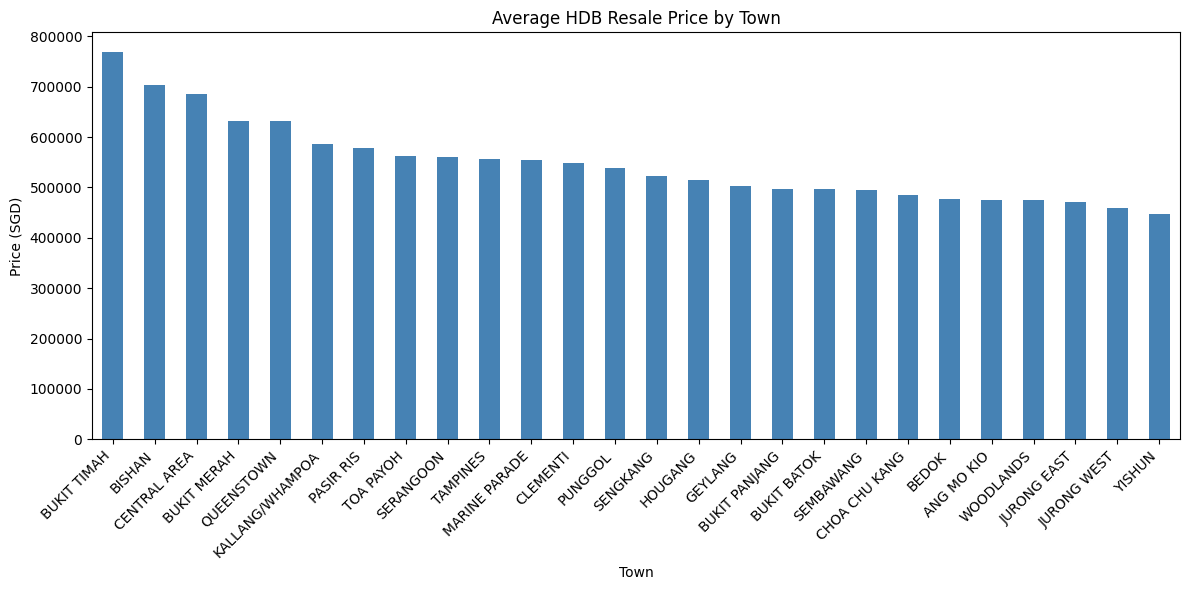

In [8]:
plt.figure(figsize=(12, 6))
town_price.plot(kind='bar', color='steelblue')
plt.title('Average HDB Resale Price by Town')
plt.xlabel('Town')
plt.ylabel('Price (SGD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/price_by_town.png', dpi=150)
plt.show()

## 2. Does a higher floor cost more?

Grouping by `storey_range` gives a dramatic answer: the `49 TO 51` band averages about 2.6
times the `01 TO 03` band. Before using a number like that, I checked how many sales are
actually behind each band.

In [9]:
# How many sales in each storey band, and how many towns do they come from?
storey_check = df.groupby('storey_range').agg(
    sales=('resale_price', 'size'),
    towns=('town', 'nunique'),
    avg_price=('resale_price', 'mean')
)

storey_check.tail(6).round(0)

,sales,towns,avg_price
storey_range,,,
34 TO 36,579,11,895027.0
37 TO 39,480,9,909337.0
40 TO 42,225,8,977901.0
43 TO 45,67,3,1090447.0
46 TO 48,45,3,1131352.0
49 TO 51,19,1,1228833.0


The `49 TO 51` band holds **19 sales out of 216,375**, and all 19 are in the same town -
Central Area.

So the 2.6x is not a floor premium. It is the most expensive town in Singapore showing up
under a storey label. The same applies, less severely, to every band above the 40th storey.

In [10]:
top_band = df[df['storey_range'] == '49 TO 51']

print("Sales in 49 TO 51:", len(top_band), "out of", len(df))
print("Share:", round(len(top_band) / len(df) * 100, 4), "%")
print("Towns:", top_band['town'].unique())

Sales in 49 TO 51: 19 out of 216375
Share: 0.0088 %
Towns: <StringArray>
['CENTRAL AREA']
Length: 1, dtype: str


### Comparing like with like

To see the floor effect on its own, I hold the other things constant. I take 4-room flats
only, and compare each sale against the average of its own town, flat type and year - so
what is left is the storey difference, not the town difference.

In [11]:
df4 = df[df['flat_type'] == '4 ROOM'].copy()

# Midpoint of the storey band, e.g. "10 TO 12" -> 11
bounds = df4['storey_range'].str.extract(r'(\d+) TO (\d+)').astype(int)
df4['storey_mid'] = bounds.mean(axis=1)

groups = df4.groupby(['town', 'flat_type', 'year'])
df4['psm_vs_group'] = df4['price_per_sqm'] - groups['price_per_sqm'].transform('mean')
df4['storey_vs_group'] = df4['storey_mid'] - groups['storey_mid'].transform('mean')

# Slope of price per sqm against storey, once town / flat type / year are held constant
controlled = df4['psm_vs_group'].cov(df4['storey_vs_group']) / df4['storey_vs_group'].var()
raw = df4['price_per_sqm'].cov(df4['storey_mid']) / df4['storey_mid'].var()

print("Raw slope        :", round(raw, 1), "SGD per sqm, per floor")
print("Controlled slope :", round(controlled, 1), "SGD per sqm, per floor")
print("Raw is inflated by", round((raw / controlled - 1) * 100), "%")
print()
print("Controlled effect of 10 floors:", round(controlled * 10 / df4['price_per_sqm'].mean() * 100, 1), "%")

Raw slope        : 132.8 SGD per sqm, per floor
Controlled slope : 87.0 SGD per sqm, per floor
Raw is inflated by 53 %

Controlled effect of 10 floors: 15.7 %


So there is a real floor premium, but it is about **15% per 10 floors**, not 2.6x.
Comparing raw averages overstates it by roughly half.

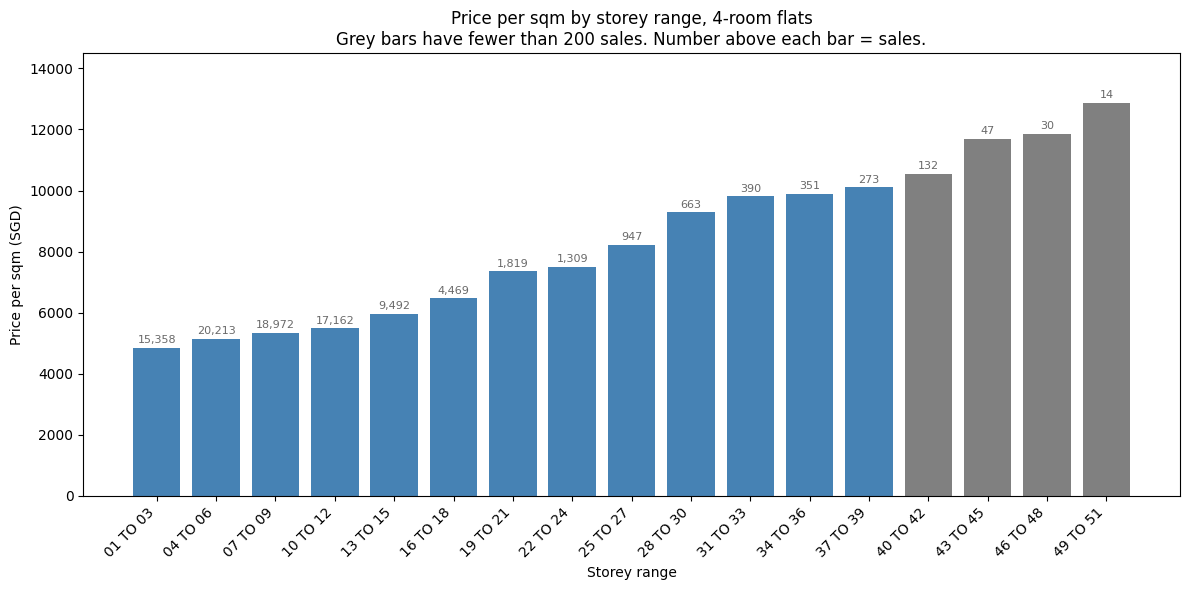

In [12]:
storey = df4.groupby('storey_range').agg(
    avg_psm=('price_per_sqm', 'mean'),
    sales=('price_per_sqm', 'size')
)

# Bands with very few sales get a grey bar - the average there is not reliable
colors = ['grey' if n < 200 else 'steelblue' for n in storey['sales']]

plt.figure(figsize=(12, 6))
plt.bar(range(len(storey)), storey['avg_psm'], color=colors)

for i, (psm, n) in enumerate(zip(storey['avg_psm'], storey['sales'])):
    plt.text(i, psm + 150, format(n, ','), ha='center', fontsize=8, color='dimgrey')

plt.xticks(range(len(storey)), storey.index, rotation=45, ha='right')
plt.title('Price per sqm by storey range, 4-room flats\nGrey bars have fewer than 200 sales. Number above each bar = sales.')
plt.xlabel('Storey range')
plt.ylabel('Price per sqm (SGD)')
plt.ylim(0, 14500)
plt.tight_layout()
plt.savefig('images/price_by_floor.png', dpi=150)
plt.show()

## 3. Price per square metre by town

Same as section 1, but adjusted for flat size.

In [13]:
psm_by_town = df.groupby('town')['price_per_sqm'].mean().sort_values(ascending=False)
psm_by_town.head(10).round(0)

town
CENTRAL AREA       8166.0
QUEENSTOWN         7497.0
BUKIT MERAH        7191.0
BUKIT TIMAH        6949.0
KALLANG/WHAMPOA    6688.0
BISHAN             6522.0
MARINE PARADE      6341.0
TOA PAYOH          6321.0
CLEMENTI           6291.0
GEYLANG            5923.0
Name: price_per_sqm, dtype: float64

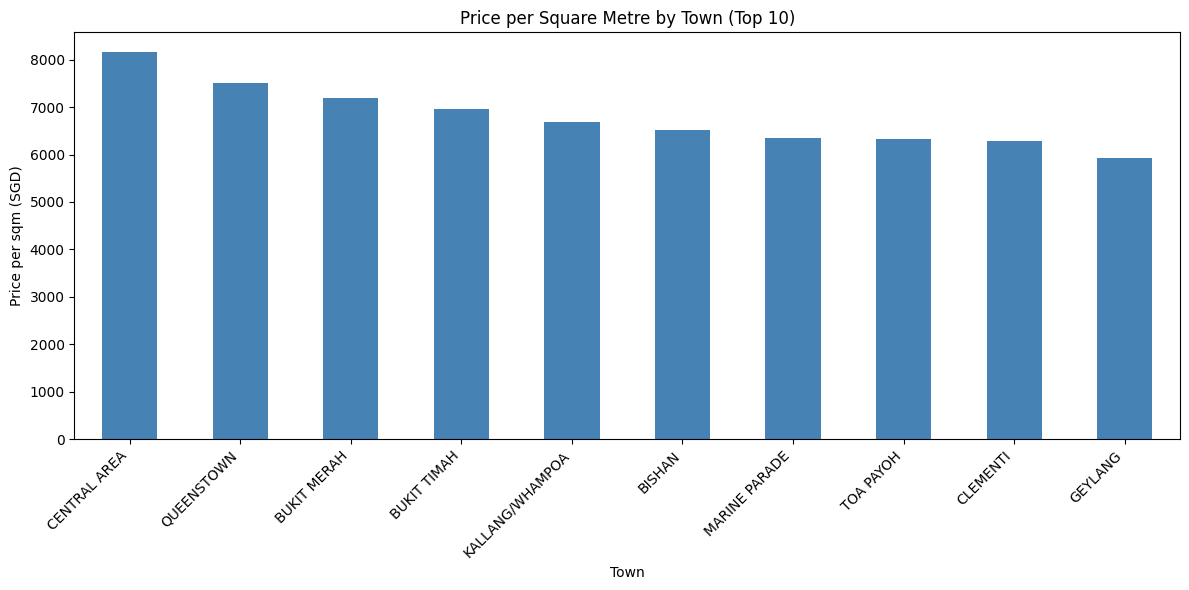

In [14]:
plt.figure(figsize=(12, 6))
psm_by_town.head(10).plot(kind='bar', color='steelblue')
plt.title('Price per Square Metre by Town (Top 10)')
plt.xlabel('Town')
plt.ylabel('Price per sqm (SGD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/price_per_sqm_top10.png', dpi=150)
plt.show()

## 4. Is there a cliff at 60 years of remaining lease?

The common view is that HDB prices drop sharply once the remaining lease falls under
about 60 years. I used 2024 sales only, and 4-room flats only, so that year and flat size
do not interfere.

In [15]:
recent = df4[df4['year'] == 2024].copy()

bins = [40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 99]
recent['lease_band'] = pd.cut(recent['lease_years'], bins)

lease = recent.groupby('lease_band', observed=True).agg(
    avg_psm=('price_per_sqm', 'mean'),
    sales=('price_per_sqm', 'size')
)
lease = lease[lease['sales'] >= 100]
lease.round(0)

,avg_psm,sales
lease_band,,
"(45, 50]",6073.0,143
"(50, 55]",5814.0,553
"(55, 60]",5637.0,1075
"(60, 65]",5741.0,1774
"(65, 70]",5592.0,534
"(70, 75]",5686.0,1478
"(75, 80]",6439.0,1095
"(80, 85]",8388.0,437
"(85, 90]",7654.0,1335


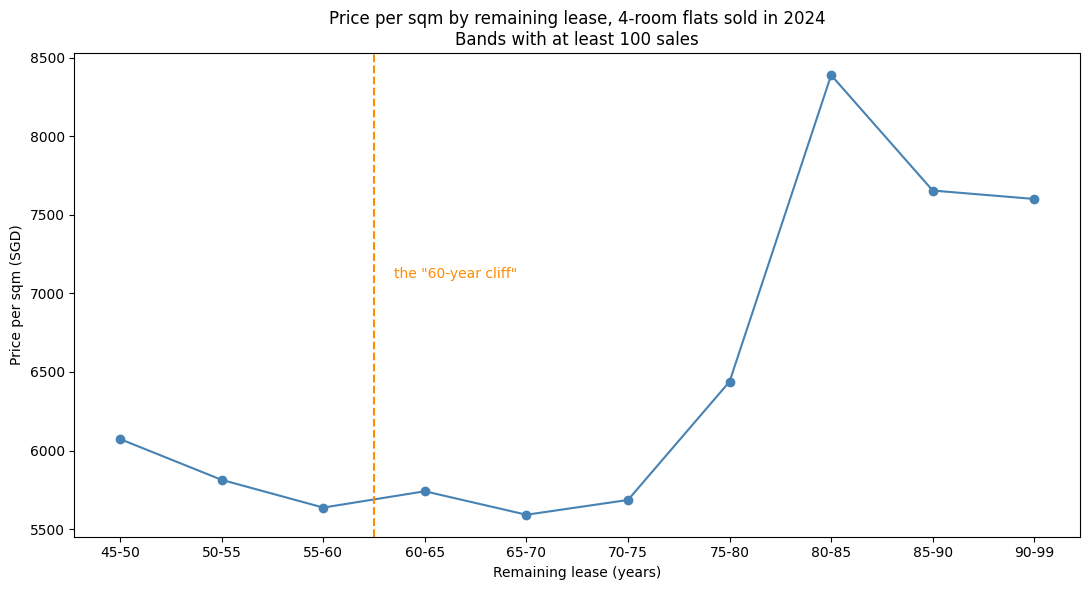

In [16]:
labels = [str(int(i.left)) + '-' + str(int(i.right)) for i in lease.index]

plt.figure(figsize=(11, 6))
plt.plot(range(len(lease)), lease['avg_psm'], marker='o', color='steelblue')
plt.axvline(labels.index('55-60') + 0.5, color='darkorange', linestyle='--')
plt.text(labels.index('55-60') + 0.7, 7100, 'the "60-year cliff"', color='darkorange')

plt.xticks(range(len(lease)), labels)
plt.title('Price per sqm by remaining lease, 4-room flats sold in 2024\nBands with at least 100 sales')
plt.xlabel('Remaining lease (years)')
plt.ylabel('Price per sqm (SGD)')
plt.tight_layout()
plt.savefig('images/price_by_lease.png', dpi=150)
plt.show()

There is no cliff. The line is flat through the 60-year mark, and flats with 45-50 years
left sell for *more* per sqm than flats with 60-75 years left.

That looked wrong until I checked where those flats are - the shortest leases are in the
oldest estates, which are the central ones. So this is the same trap as section 2: the town
is doing the work.

In [17]:
# Same comparison as section 2, but for lease instead of storey
for low, high in [(45, 60), (60, 75), (75, 95)]:
    band = recent[(recent['lease_years'] >= low) & (recent['lease_years'] < high)].copy()
    g = band.groupby('town')
    psm_dev = band['price_per_sqm'] - g['price_per_sqm'].transform('mean')
    lease_dev = band['lease_years'] - g['lease_years'].transform('mean')

    slope = psm_dev.cov(lease_dev) / lease_dev.var()
    pct = slope / band['price_per_sqm'].mean() * 100
    print(f"{low}-{high} years left: one extra lease year is worth {pct:+.2f}% per sqm  (n={len(band)})")

45-60 years left: one extra lease year is worth +0.95% per sqm  (n=1710)
60-75 years left: one extra lease year is worth +0.41% per sqm  (n=3818)
75-95 years left: one extra lease year is worth +0.79% per sqm  (n=6229)


Once the town is held constant, an extra year of lease is worth well under 1% per sqm, and
the effect does not accelerate below 60 years. Whatever drives the "cliff" story, it is not
visible in this dataset.

## 5. Has the gap between towns changed since 2017?

4-room flats only, comparing 2017 against 2024, keeping towns that had at least 50 sales in
both years.

In [18]:
by_year = df4.pivot_table(index='town', columns='year', values='price_per_sqm', aggfunc='mean')
counts = df4.pivot_table(index='town', columns='year', values='price_per_sqm', aggfunc='size')

growth = pd.DataFrame({
    'psm_2017': by_year[2017],
    'psm_2024': by_year[2024],
    'sales_2017': counts[2017],
    'sales_2024': counts[2024]
}).dropna()

growth = growth[(growth['sales_2017'] >= 50) & (growth['sales_2024'] >= 50)]
growth['growth_pct'] = (growth['psm_2024'] / growth['psm_2017'] - 1) * 100

growth[['psm_2017', 'psm_2024', 'growth_pct']].sort_values('growth_pct', ascending=False).round(1)

,psm_2017,psm_2024,growth_pct
town,,,
SEMBAWANG,3754.7,6325.9,68.5
WOODLANDS,3576.0,5604.2,56.7
HOUGANG,4004.4,6209.9,55.1
PASIR RIS,3840.7,5918.7,54.1
CHOA CHU KANG,3459.1,5315.8,53.7
BUKIT BATOK,4111.6,6285.7,52.9
YISHUN,3799.7,5796.6,52.6
TAMPINES,4348.8,6618.8,52.2
KALLANG/WHAMPOA,6015.5,9130.8,51.8


In [19]:
corr = growth['psm_2017'].corr(growth['growth_pct'])

gap_2017 = growth['psm_2017'].max() / growth['psm_2017'].min()
gap_2024 = growth['psm_2024'].max() / growth['psm_2024'].min()

print("Correlation between 2017 price level and later growth:", round(corr, 2))
print("Most expensive / least expensive town:")
print("  2017:", round(gap_2017, 2), "x")
print("  2024:", round(gap_2024, 2), "x")

Correlation between 2017 price level and later growth: -0.64
Most expensive / least expensive town:
  2017: 2.36 x
  2024: 1.97 x


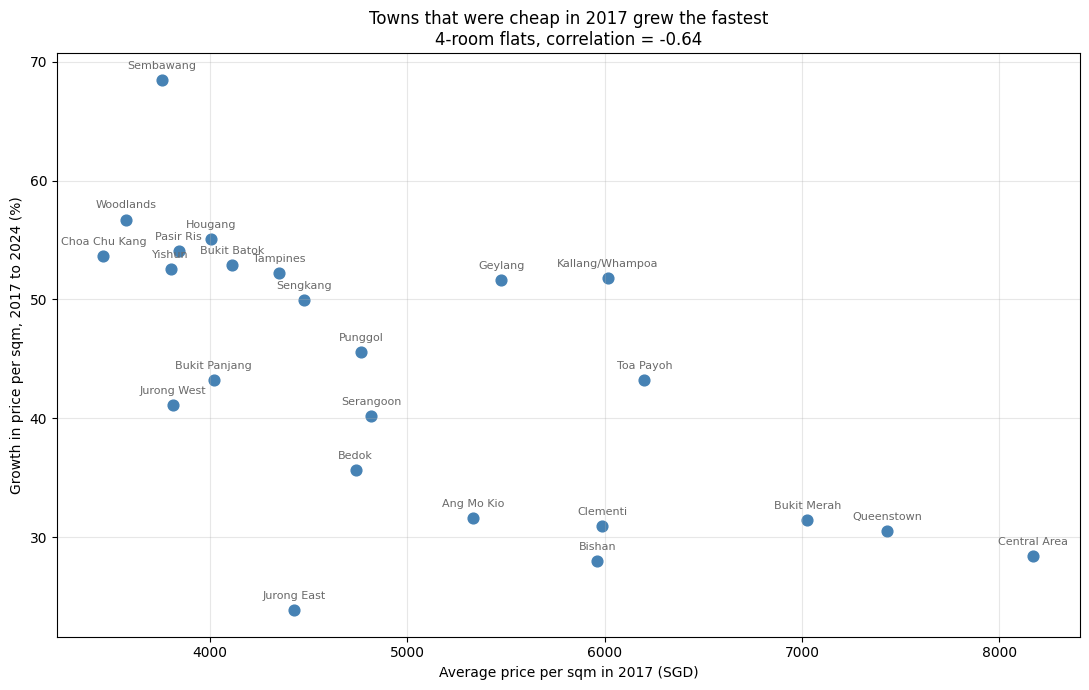

In [20]:
plt.figure(figsize=(11, 7))
plt.scatter(growth['psm_2017'], growth['growth_pct'], s=60, color='steelblue')

for town, row in growth.iterrows():
    plt.annotate(town.title(), (row['psm_2017'], row['growth_pct']),
                 xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8, color='dimgrey')

plt.title('Towns that were cheap in 2017 grew the fastest\n4-room flats, correlation = ' + str(round(corr, 2)))
plt.xlabel('Average price per sqm in 2017 (SGD)')
plt.ylabel('Growth in price per sqm, 2017 to 2024 (%)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('images/growth_by_town.png', dpi=150)
plt.show()

The cheapest towns grew the most and the most expensive grew the least, so the gap narrowed
from 2.36x to 1.97x. The ranking of towns barely moved - Central Area is still the most
expensive - but the multiple between the ends is smaller than it was.

## Summary

In [21]:
print("1. Town")
print("   Bukit Timah averages the most, Yishun the least - a 72% gap.")
print()
print("2. Storey")
print("   A real premium, but about 15% per 10 floors once town, flat type and year are held constant.")
print("   The raw comparison overstates it by roughly 50%, and the top storey bands are too thin to use.")
print()
print("3. Remaining lease")
print("   No cliff at 60 years. Held constant by town, one extra lease year is worth under 1% per sqm.")
print("   Flats with 45-50 years left are more expensive per sqm than flats with 60-75 years left,")
print("   because the short leases are in the older central estates.")
print()
print("4. Change since 2017")
print("   Cheaper towns grew faster (correlation -0.64). The gap narrowed from 2.36x to 1.97x.")

1. Town
   Bukit Timah averages the most, Yishun the least - a 72% gap.

2. Storey
   A real premium, but about 15% per 10 floors once town, flat type and year are held constant.
   The raw comparison overstates it by roughly 50%, and the top storey bands are too thin to use.

3. Remaining lease
   No cliff at 60 years. Held constant by town, one extra lease year is worth under 1% per sqm.
   Flats with 45-50 years left are more expensive per sqm than flats with 60-75 years left,
   because the short leases are in the older central estates.

4. Change since 2017
   Cheaper towns grew faster (correlation -0.64). The gap narrowed from 2.36x to 1.97x.


## So what

Three of these findings change what a buyer should actually look at.

**Height is worth less than the listings suggest, and only in the right place.** Ten floors is
worth roughly 16% per sqm once the town is held constant. Paying a large premium for a high
floor inside an already expensive town means paying for the location twice - the height is
already in the town price.

**Screening flats by remaining lease alone filters on the wrong variable.** A 45-55 year lease
is not the discount the "60-year cliff" story implies, because those flats sit in mature central
estates and are priced up by that. A buyer avoiding short leases on principle is ruling out
central locations without meaning to.

**If growth matters more than the address, the record points the other way round.** Since 2017
the cheapest towns grew the fastest and the most expensive grew the slowest, and the gap between
the ends narrowed from 2.36x to 1.97x.

One caveat on the last point: this describes what has already happened. Eight years of one
direction is not a forecast, and the towns that grew fastest were also the ones with the most
room to catch up.

## Limitations

- Every comparison above holds town, flat type and year constant, but not flat model,
  block age or distance to an MRT station. Some of what is left may still belong to those.
- Comparing each sale against its own town / type / year average is a simple way to control
  for them. A regression with all the variables at once would be a stronger test.
- 2025 data stops in September, so 2025 is not used in the year-on-year comparison.
- The dataset records what flats sold for, not what they were listed at, so nothing here
  says anything about how long a flat takes to sell.